# Compare the fracture algorithms of Horvat and Tziperman (2015) with a log-normal

In [20]:
import xarray as xr
import cf_xarray
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client


import matplotlib.path as mpath
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.feature as cft
import cftime

# Stats
import geopandas as gpd
from scipy.interpolate import griddata

# Plotting
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import cmocean.cm as cmo

import os
import requests
import zipfile


from tqdm.notebook import tqdm 
import calendar
import pandas as pd
from datetime import datetime

# CLEANUP
%matplotlib inline
import seaborn as sns
import calendar

In [21]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40373 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/40373/status,
Dashboard: /proxy/40373/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46451,Workers: 0
Dashboard: /proxy/40373/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34185,Total threads: 1
Dashboard: /proxy/40631/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:39433,


2026-03-11 10:57:22,756 - tornado.application - ERROR - Uncaught exception GET /individual-task-stream/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='gadi-cpu-bdw-0024.gadi.nci.org.au:21120', method='GET', uri='/individual-task-stream/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("

In [22]:
print(client.dashboard_link)

/proxy/40373/status


In [23]:
# ["baseline-1deg", "wave-profile-1deg", "wave-propagation-1deg"],
import socket
from datetime import timedelta

def get_path(experiments):
    hostname = socket.gethostname()
    if "gadi" in hostname:
        machine = "gadi"
        #path = "/g/data/ps29/nd0349/runs/cice6/"
        path = "/scratch/ps29/nd0349/CICE_RUNS/"
        fig_path = "/home/566/nd0349/access-om3-analysis/figures/"
    elif "setonix" in hostname:
        machine = "setonix"
    else:
        machine = "noahday"
        path = "/Users/noahday/GitHub/cice-dev/cice-dirs/runs/"
        fig_path = "/Users/noahday/GitHub/access-om3-analysis/figures/"

    print(f"Running on {machine}")
        
    return path, fig_path


In [24]:
def prep_data_import(experiment, histfreq = "m"):
    expt_path, fig_path = get_path(experiment)
    
    path = os.path.join(expt_path, experiment, "history/")
    if histfreq == "h":
        file_pattern = os.path.join(path, "iceh_01h.????-??-??-?????.nc")
        time_delta = timedelta(minutes=30)
    elif histfreq == "d":
        file_pattern = os.path.join(path, "iceh.????-??-??.nc")
        time_delta = timedelta(hours=12)
    elif histfreq == "m":
        file_pattern = os.path.join(path, "iceh.????-??.nc")  # Adjust this if needed
        time_delta = timedelta(days=16)
    files = sorted(glob.glob(file_pattern))
    
    if not files:
        print(f"❌ No files found for {experiment}, skipping...")
    
    basic_ice_vars = ["aice", "hi", "iage", "fsdrad", "afsd", "NFSD"]
    atm_forcing_vars = ["Tair", "uatm", "vatm", "Qref", "fswdn", "flwdn", "snow"]
    thermo_vars = ["meltb", "meltl", "meltt"]
    # 10m Air temperature, wind components, 2m specific humiditiy, incoming long wave radiation, incoming long wave radiation
    # Tair, uatm, vatm, Qa, fsw, flw, fsnow from ice_forcing.F90/JRA55_data
    
    ocn_forcing_vars = ["sst", "sss", "uocn", "vocn"]
    wave_forcing_vars = ["wave_sig_ht"] # peak period? MWD?
    
    VARS = basic_ice_vars + atm_forcing_vars + ocn_forcing_vars + wave_forcing_vars + thermo_vars
    VARS_with_m = VARS + [var + "_m" for var in VARS]
    VARS = VARS + VARS_with_m
    keep_vars = ["TLAT", "TLON", "time", "tarea", "HTE", "hte"] + VARS
    
    sample_ds = xr.open_dataset(files[0])
    drop_vars = [var for var in sample_ds.variables if var not in keep_vars]


    return files[:365], drop_vars

histfreq = "m"
files, drop_vars = prep_data_import("wave-propogation-1deg-hs-0p001", histfreq=histfreq)
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ds_wim = xr.open_mfdataset(
    files,
    combine="by_coords",
    decode_times=False,
    # use_cftime=True,      # ensures all times use cftime objects
    drop_variables=drop_vars,
    # decode_times=time_coder,
)

rename_dict = {var: var[:-2] for var in ds_wim.data_vars if var.endswith("_m")}
ds_wim = ds_wim.rename(rename_dict)
ds_wim = ds_wim.roll(ni=80, roll_coords=True)

ds_wim_time = xr.Dataset(coords={"time": ds_wim["time"]})
ds_wim_time = xr.decode_cf(ds_wim_time)
time_dt = ds_wim_time.time

# ds_wim["time"] = pd.to_datetime(time_dt) #- time_delta

# ds_wim['HTE'] = ds_mcw['HTE']
ds_wim

Running on gadi


/jobfs/162811542.gadi-pbs/ipykernel_2500910/1626719327.py:42: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_wim = xr.open_mfdataset(


<xarray.Dataset> Size: 247MB
Dimensions:      (time: 19, nj: 300, ni: 360, nf: 12)
Coordinates:
  * time         (time) float64 152B 31.0 59.0 90.0 120.0 ... 516.0 546.0 577.0
    TLON         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    TLAT         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    NFSD         (nf) float32 48B dask.array<chunksize=(12,), meta=np.ndarray>
Dimensions without coordinates: nj, ni, nf
Data variables: (12/19)
    tarea        (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    hi           (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    aice         (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    uatm         (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    vatm         (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    fswdn        (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ...           ...
    meltb        (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    meltl        (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    iage         (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    wave_sig_ht  (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    fsdrad       (time, nj, ni) float32 8MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    afsd         (time, nf, nj, ni) float32 98MB dask.array<chunksize=(1, 12, 300, 360), meta=np.ndarray>
Attributes:
    title:               sea ice model output for CICE
    contents:            Diagnostic and Prognostic Variables
    source:              Los Alamos Sea Ice Model, CICE_6.6.0
    comment:             All years have exactly 365 days
    comment2:            File written on model date 20100201
    comment3:            seconds elapsed into model date:      0
    time_period_freq:    month_1
    time_axis_position:  end
    conventions:         CF-1.0
    history:             This dataset was created on 2026-02-24 at 16:02:46.7
    io_flavor:           io_netcdf

In [25]:
# ds_wim["time"] = pd.to_datetime(time_dt) #- time_delta

# ds_wim['HTE'] = ds_mcw['HTE']
ds_wim.time

<xarray.DataArray 'time' (time: 19)> Size: 152B
array([ 31.,  59.,  90., 120., 151., 181., 212., 243., 273., 304., 334., 365.,
       396., 424., 455., 485., 516., 546., 577.])
Coordinates:
  * time     (time) float64 152B 31.0 59.0 90.0 120.0 ... 516.0 546.0 577.0
Attributes:
    long_name:  time
    units:      days since 2010-01-01 00:00:00
    calendar:   noleap
    bounds:     time_bounds

In [26]:
time_dt

<xarray.DataArray 'time' (time: 19)> Size: 152B
array([cftime.DatetimeNoLeap(2010, 2, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 3, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 4, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 5, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 6, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 7, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 8, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 9, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 10, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 11, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2010, 12, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2011, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2011, 2, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2011, 3, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2011, 4, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2011, 5, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2011, 6, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2011, 7, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2011, 8, 1, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 152B 2010-02-01 00:00:00 ... 2011-08-01 00:00:00
Attributes:
    long_name:  time
    bounds:     time_bounds

In [27]:
files, drop_vars = prep_data_import("wave-propogation-1deg-icdp-0p001", histfreq=histfreq)
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ds_ln = xr.open_mfdataset(
    files,
    combine="by_coords",
    decode_times=False,
    # use_cftime=True,      # ensures all times use cftime objects
    drop_variables=drop_vars,
    # decode_times=time_coder,
)

rename_dict = {var: var[:-2] for var in ds_ln.data_vars if var.endswith("_m")}
ds_ln = ds_ln.rename(rename_dict)
ds_ln = ds_ln.roll(ni=80, roll_coords=True)

ds_ln_time = xr.Dataset(coords={"time": ds_ln["time"]})
ds_ln_time = xr.decode_cf(ds_ln_time)
time_dt = ds_ln_time.time

# ds_ln["time"] = pd.to_datetime(time_dt)

Running on gadi


/jobfs/162811542.gadi-pbs/ipykernel_2500910/2347332294.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_ln = xr.open_mfdataset(


In [28]:

files, drop_vars = prep_data_import("wave-propagation-1deg", histfreq=histfreq)
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
ds_ht = xr.open_mfdataset(
    files,
    combine="by_coords",
    decode_times=False,
    # use_cftime=True,      # ensures all times use cftime objects
    drop_variables=drop_vars,
    # decode_times=time_coder,
)

rename_dict = {var: var[:-2] for var in ds_ht.data_vars if var.endswith("_m")}
ds_ht = ds_ht.rename(rename_dict)
ds_ht = ds_ht.roll(ni=80, roll_coords=True)

import cftime

ds_ht["time"] = [
    cftime.DatetimeGregorian(2010, t.month, t.day)
    for t in ds_ht.time.values
]

# ds_ht = xr.decode_cf(ds_ht)
ds_ht = ds_ht.convert_calendar("gregorian", use_cftime=True)
ds_ht_time = xr.Dataset(coords={"time": ds_ht["time"]})
ds_ht_time = xr.decode_cf(ds_ht_time)
time_dt = ds_ht_time.time

# ds_ht["time"] = pd.to_datetime(time_dt)

Running on gadi


/jobfs/162811542.gadi-pbs/ipykernel_2500910/1091782666.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_ht = xr.open_mfdataset(


AttributeError: 'numpy.float64' object has no attribute 'month'

In [ ]:
time_dt

In [29]:
ds_ht

<xarray.Dataset> Size: 778MB
Dimensions:      (time: 60, nj: 300, ni: 360, nf: 12)
Coordinates:
  * time         (time) float64 480B 31.0 59.0 90.0 ... 1.794e+03 1.825e+03
    TLON         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    TLAT         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    NFSD         (nf) float32 48B dask.array<chunksize=(12,), meta=np.ndarray>
Dimensions without coordinates: nj, ni, nf
Data variables: (12/19)
    tarea        (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    hi           (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    aice         (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    uatm         (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    vatm         (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    fswdn        (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ...           ...
    meltb        (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    meltl        (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    iage         (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    wave_sig_ht  (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    fsdrad       (time, nj, ni) float32 26MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    afsd         (time, nf, nj, ni) float32 311MB dask.array<chunksize=(1, 12, 300, 360), meta=np.ndarray>
Attributes:
    title:               sea ice model output for CICE
    contents:            Diagnostic and Prognostic Variables
    source:              Los Alamos Sea Ice Model, CICE_6.6.0
    comment:             This year has 365 days
    comment2:            File written on model date 20100201
    comment3:            seconds elapsed into model date:      0
    time_period_freq:    month_1
    time_axis_position:  end
    conventions:         CF-1.0
    history:             This dataset was created on 2026-01-28 at 15:19:59.4
    io_flavor:           io_netcdf

## Plot the averaged FSD

In [30]:

def get_split_power_law_pdf(x, x_pr, gamma0=1.15, gamma1=2.5, x_crit=40, x_min=None, q=0.05):
    """Split (broken) power-law PDF on [min, inf].
    """
    if x_min is None:
        x_min = x.min()

    P0 = 1 - q * (x_pr / x_crit)**(gamma1)

    # Normalisation constants
    beta0 = 1/(x_min**(-gamma0) - x_crit**(-gamma0))
    C1 = P0 * beta0 * gamma0 #/ (x**(gamma0 + 1))

    # To make it smooth
    p1_xcrit = P0 * beta0 * gamma0 / x_crit**(gamma0 + 1)
    C2 = p1_xcrit * x_crit**(gamma1 + 1) #/  x **(gamma1 + 1)


    # Piecewise PDF
    pdf = np.where(
        x < x_crit,
        C1 * x**(-(gamma0 + 1)),
        C2 * x**(-(gamma1 + 1))
    )
    return pdf

split_power_law = get_split_power_law_pdf(ds_wim['NFSD'], 10, x_crit=10) # Split at 20 instead of 40 since this is radius and then half again due to error
split_power_law

array([5.21501005e-01, 3.23355570e-02, 2.06544320e-03, 2.26873526e-04,
       3.38667669e-05, 6.24582526e-06, 1.36468020e-06, 3.46113012e-07,
       1.00814674e-07, 3.35289982e-08, 1.26903981e-08, 5.45569057e-09],
      dtype=float32)

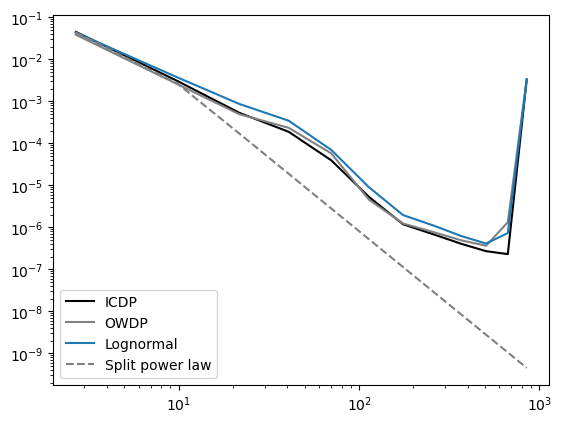

In [33]:

plt.plot(ds_wim['NFSD'], ds_wim['afsd'].where(ds_wim['aice'] > 0.15).mean(dim=['time', 'nj', 'ni']), label='ICDP', c='black')
plt.plot(ds_ht['NFSD'], ds_ht['afsd'].where(ds_ht['aice'] > 0.15).mean(dim=['time', 'nj', 'ni']), label='OWDP', c='gray')
fsd_ln = ds_ln['afsd'].where(ds_ln['aice'] > 0.15).mean(dim=['time', 'nj', 'ni'])
plt.plot(ds_ln['NFSD'], fsd_ln, label='Lognormal')
plt.plot(ds_ln['NFSD'], split_power_law/split_power_law.max()*fsd_ln.values.max(), label='Split power law', color='gray', ls='--')
# plt.axvline(10, '--', c='gray')
# plt.axvline(40, '--', c='gray')
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [32]:
ds_ht['fsdrad'].where(ds_ht['aice'] > 0.15).mean(dim=['nj', 'ni'])

<xarray.DataArray 'fsdrad' (time: 60)> Size: 240B
dask.array<mean_agg-aggregate, shape=(60,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) float64 480B 31.0 59.0 90.0 ... 1.794e+03 1.825e+03

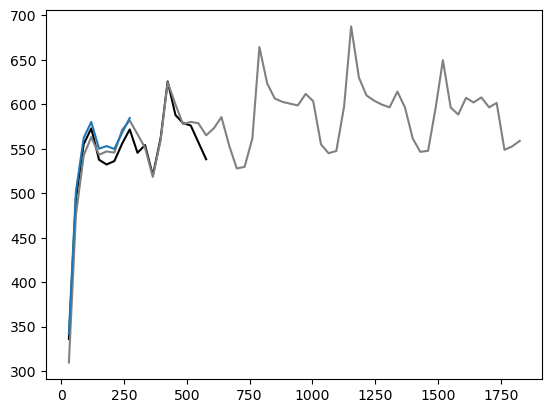

In [21]:
plt.plot(ds_wim['time'], ds_wim['fsdrad'].where(ds_wim['aice'] > 0.15).mean(dim=['nj', 'ni']), label='HT15 ', c='black')
plt.plot(ds_ht['time'], ds_ht['fsdrad'].where(ds_ht['aice'] > 0.15).mean(dim=['nj', 'ni']), label='HT15 frzmlt', c='gray')
plt.plot(ds_ln['time'], ds_ln['fsdrad'].where(ds_ln['aice'] > 0.15).mean(dim=['nj', 'ni']), label='t_w=1')

## Plot a map of mean FSD and the difference

In [34]:
time_idx = 8

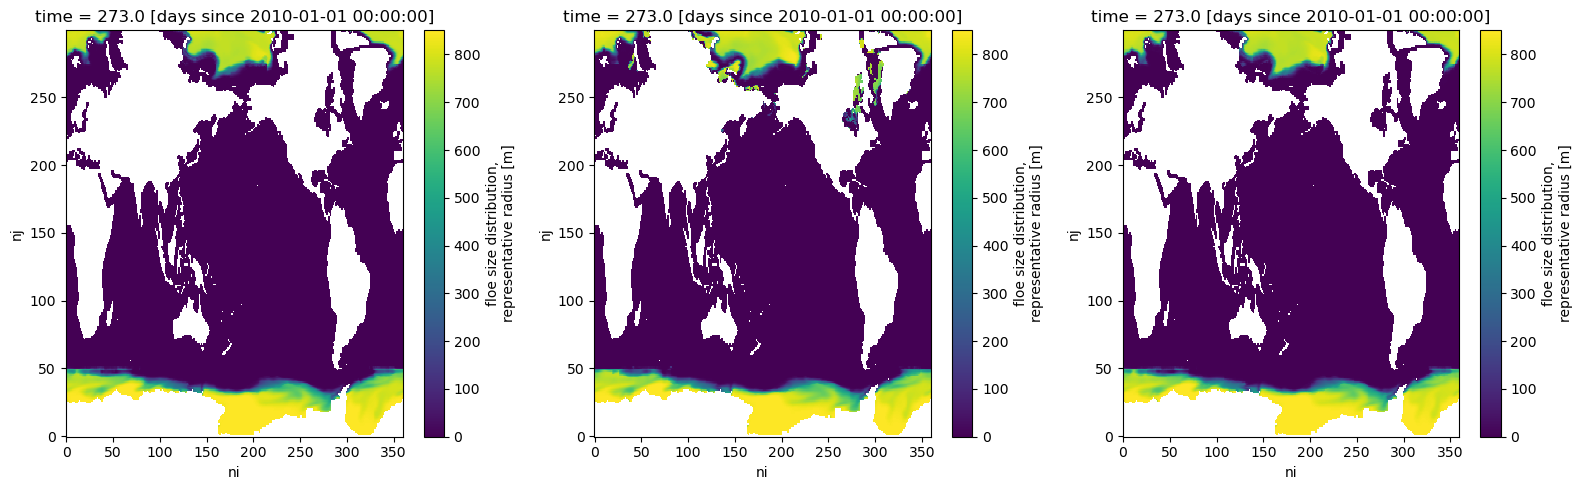

In [35]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

ds_wim['fsdrad'].isel(time=time_idx).plot(ax=axes[0])

ds_ht['fsdrad'].isel(time=time_idx).plot(ax=axes[1])

ds_ln['fsdrad'].isel(time=time_idx).plot(ax=axes[2])

plt.tight_layout()
plt.show()

In [42]:
ds_plot

<xarray.Dataset> Size: 14MB
Dimensions:      (nj: 300, ni: 360, nf: 12)
Coordinates:
    time         float64 8B 273.0
    TLON         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    TLAT         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    NFSD         (nf) float32 48B dask.array<chunksize=(12,), meta=np.ndarray>
Dimensions without coordinates: nj, ni, nf
Data variables: (12/19)
    tarea        (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    hi           (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    aice         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    uatm         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    vatm         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    fswdn        (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    ...           ...
    meltb        (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    meltl        (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    iage         (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    wave_sig_ht  (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    fsdrad       (nj, ni) float32 432kB dask.array<chunksize=(300, 360), meta=np.ndarray>
    afsd         (nf, nj, ni) float32 5MB dask.array<chunksize=(12, 300, 360), meta=np.ndarray>
Attributes:
    title:               sea ice model output for CICE
    contents:            Diagnostic and Prognostic Variables
    source:              Los Alamos Sea Ice Model, CICE_6.6.0
    comment:             All years have exactly 365 days
    comment2:            File written on model date 20100201
    comment3:            seconds elapsed into model date:      0
    time_period_freq:    month_1
    time_axis_position:  end
    conventions:         CF-1.0
    history:             This dataset was created on 2026-02-24 at 16:02:46.7
    io_flavor:           io_netcdf

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


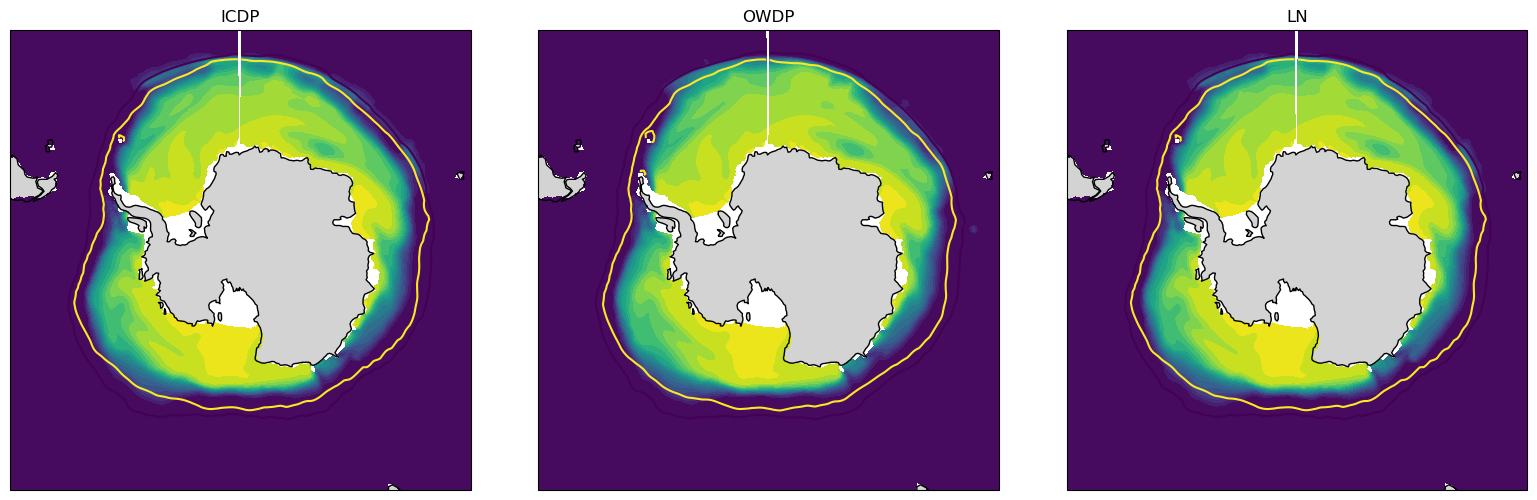

In [50]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(16, 5),
    subplot_kw={'projection': ccrs.SouthPolarStereo()}  # South Polar projection
)

datasets = [ds_wim, ds_ht, ds_ln]
titles = ["ICDP", "OWDP", "LN"]
projection = ccrs.SouthPolarStereo()
# Make sure your latitude is in degrees south and longitude is -180 to 180
for ax, ds, title in zip(axes, datasets, titles):
    # Plot with pcolormesh through xarray
    ds_plot = ds['fsdrad'].isel(time=time_idx).copy()
    cf = ax.contourf(
        ds['TLON'].values,
        ds['TLAT'].values,
        ds_plot.values,
        levels=20,
        transform=ccrs.PlateCarree(),
        cmap='viridis'
    )
    ds_plot = ds['aice'].isel(time=time_idx).copy()
    ax.contour(
        ds['TLON'].values,
        ds['TLAT'].values,
        ds_plot.values,
        levels=[0.15, 0.8],
        transform=ccrs.PlateCarree(),
        color='white',
    )
    # cs = add_ice_contours(ax, ds_plot, hemisphere, projection)
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.set_title(title)
    ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

NameError: name 'dt' is not defined

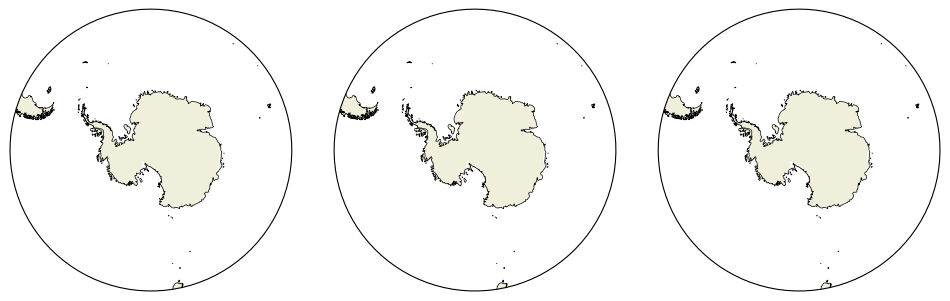

In [37]:
sys.path.append("/home/566/nd0349/access-om3-analysis/functions")
from plot_settings import *
hemisphere = "south"
fig, axes, projection = basic_axis([1,3], hemisphere=hemisphere)

ds_plot = ds_ht.isel(time=time_idx).copy()
axes[0].contourf(
    dt[dt.groups[1]]["TLON"].values,
    dt[dt.groups[1]]["TLAT"].values,
    data.values,
    cmap=settings.get("cmap"),
    vmin=vmin,
    vmax=vmax,
    levels=20,
    transform=ccrs.PlateCarree()
)
cs = add_ice_contours(axes[0], ds_plot, hemisphere, projection)

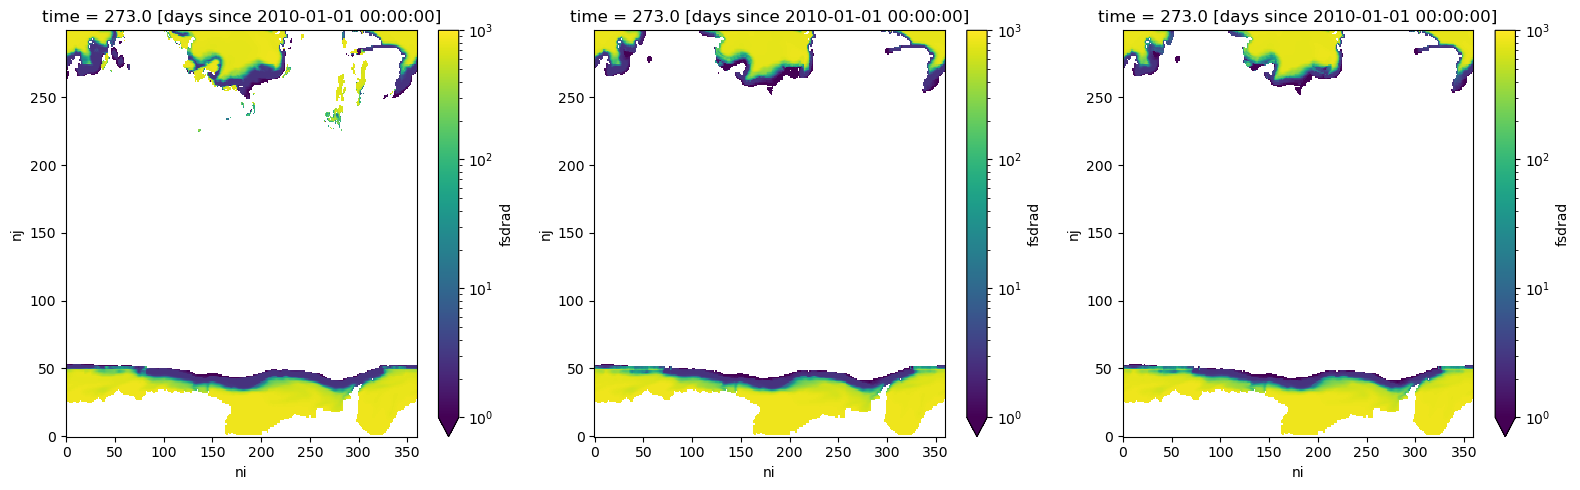

In [38]:
import matplotlib.colors as colors
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5))

# Choose vmin/vmax if needed to avoid log(0) issues
vmin = 1  # smallest value > 0
vmax = 1e3# or ds_wim['fsdrad'].max().values, etc.

ds_ht['fsdrad'].isel(time=time_idx).plot(
    ax=axes[0],
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    cbar_kwargs={'label': 'fsdrad'}
)

# Plot with log color scale
ds_wim['fsdrad'].isel(time=time_idx).plot(
    ax=axes[1],
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    cbar_kwargs={'label': 'fsdrad'}
)

ds_ln['fsdrad'].isel(time=time_idx).plot(
    ax=axes[2],
    norm=colors.LogNorm(vmin=vmin, vmax=vmax),
    cbar_kwargs={'label': 'fsdrad'}
)

plt.tight_layout()
plt.show()

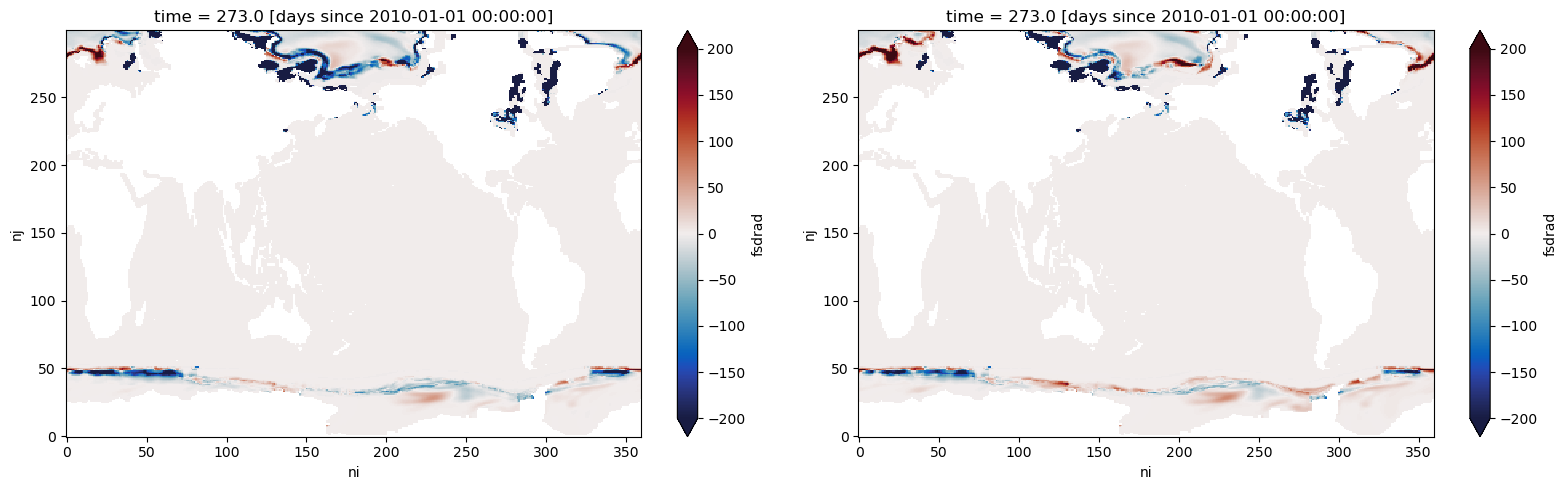

In [55]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

(ds_wim['fsdrad'].isel(time=time_idx)-ds_ht['fsdrad'].isel(time=time_idx)).plot(ax=axes[0], vmin=-200, vmax=200, cmap=cmo.balance)
(ds_ln['fsdrad'].isel(time=time_idx)-ds_ht['fsdrad'].isel(time=time_idx)).plot(ax=axes[1], vmin=-200, vmax=200, cmap=cmo.balance)

plt.tight_layout()
plt.show()

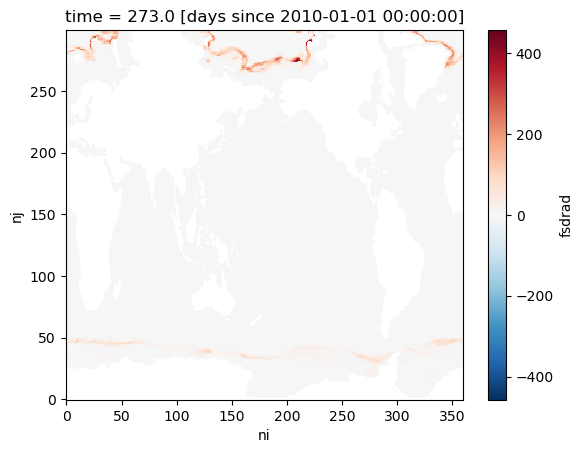

In [37]:
(ds_ln['fsdrad'].isel(time=time_idx)-ds_wim['fsdrad'].isel(time=time_idx)).plot()
plt.show()

In [ ]:
def _get_mask(ds, definition, hemisphere, threshold=None):
    # Set defaults for each definition
    defaults = {'wave_sig_ht': 0.05, 'aice': 0.8, 'fsdrad': 500}
    if threshold is None:
        try:
            threshold = defaults[definition]
        except KeyError:
            raise ValueError(f"Unknown definition: {definition}")

    # Example for aice
    aice_var = _get_var(ds, ['aice_m', 'aice'])
    wave_var = _get_var(ds, ['wave_sig_ht_m', 'wave_sig_ht'])
    fsd_var = _get_var(ds, ['fsdrad_m', 'fsdrad'])
    
    # Hemisphere mask
    if hemisphere == 'south':
        hemi_mask = ds['TLAT'] < 0
    elif hemisphere == 'north':
        hemi_mask = ds['TLAT'] > 0
    else:
        raise ValueError("hemisphere must be 'north' or 'south'")

    # Base ice presence mask
    base_mask = ds[aice_var] > 0.15

    # Definition-specific condition
    if definition == 'wave_sig_ht':
        cond = ds[wave_var] > threshold
    elif definition == 'aice':
        cond = ds[aice_var] < threshold
    elif definition == 'fsdrad':
        cond = ds[fsd_var] < threshold
    elif definition in ['SIE', 'SIA']:
        cond = base_mask
    else:
        raise ValueError(f"Unknown definition: {definition}")

    return base_mask & cond & hemi_mask

def _get_var(ds, names):
    """Return the first matching variable name in ds."""
    for n in names:
        if n in ds:
            return n
    raise KeyError(f"None of the variables {names} found in dataset.")

def _integrate_area(ds, mask, definition):
    if definition == "SIA":
        return ds['tarea']*ds['aice'].where(mask).sum(dim=['ni', 'nj'])
    else:
        return ds['tarea'].where(mask).sum(dim=['ni', 'nj'])

def calculate_area(ds_cice, definition='wave', threshold=0.05, integration='simple', 
                        measure='median', mask=True, method='naive', hemisphere='south', freq='monthly'):
    mask_2d = _get_mask(ds_cice, definition, hemisphere, threshold)
    
    sea_ice_extent = _integrate_area(ds_cice, mask_2d, definition) * 1e-12

    if definition in ["wave_sig_ht", "aice", "fsdrad"]:
        name = "MIZ area"
    elif definition == "SIE":
        name = "Sea ice extent"
    elif definition == "SIA":
        name = "Sea ice area"

    if freq == 'monthly':
        coords = {'month': ds_cice['month']}
    elif freq == 'daily':
        coords = {'time': ds_cice['time']}
    elif freq == 'dayofyear':
        coords = {'dayofyear': ds_cice['dayofyear']}
        
    return xr.DataArray(
        sea_ice_extent,
        dims=sea_ice_extent.dims,
        coords=coords,
        name=name,
        attrs={
            'units': '10^6 km^2',
            'description': f'MIZ extent ({definition})'
        }
    )


def _integrate_width(width, ds, method):
    if method == 'simple':
        return width.sum(dim='nj', skipna=True)
    elif method == 'weighted':
        aice_var = _get_var(ds, ['aice_m', 'aice'])
        return (width * ds[aice_var]).sum(dim='nj', skipna=True)
    else:
        raise ValueError(f"Unknown integration: {method}")

def _reduce_width(width, method, mask):
    if mask:
        width = width.where(width != 0)
    if method == 'median':
        return width.median(dim='ni', skipna=True)
    elif method == 'mean':
        return width.mean(dim='ni', skipna=True)
    else:
        raise ValueError(f"Unknown measure: {method}")

def calculate_miz_width(ds_cice, definition='wave_sig_ht', threshold=0.3, integration='simple', 
                        measure='median', mask=True, hemisphere='south', freq='monthly'):
    mask_2d = _get_mask(ds_cice, definition, hemisphere, threshold)
    
    miz_width_2d = ds_cice['HTE'].where(mask_2d) / 1000 # m to km
    miz_width_1d = _integrate_width(miz_width_2d, ds_cice, integration)
    miz_width_reduced = _reduce_width(miz_width_1d, measure, mask)

    if freq == 'monthly':
        coords = {'month': ds_cice['month']}
    elif freq == 'daily':
        coords = {'time': ds_cice['time']}
    elif freq == 'dayofyear':
        coords = {'dayofyear': ds_cice['dayofyear']}

    return xr.DataArray(
        miz_width_reduced,
        dims=miz_width_reduced.dims,
        coords=coords,
        name='miz_width',
        attrs={
            'units': 'km',
            'description': f'MIZ width ({definition})'
        }
    )

In [ ]:
ds_grid = xr.open_dataset('/g/data/vk83/configurations/inputs/access-om3/cice/grids/global.1deg/2024.05.14/grid.nc')
ds_grid
definition = 'fsdrad'
hemisphere='south'
ds_wim['HTE'] = ds_grid['hte']*1e-2
threshold= 100
miz_width_wim = calculate_miz_width(ds_wim.groupby("time.month").mean(), definition=definition, threshold=threshold, hemisphere=hemisphere, freq='monthly', integration='weighted')
miz_width_wim

In [ ]:
ds_ln['HTE'] = ds_grid['hte']*1e-2
ds_ht['HTE'] = ds_grid['hte']*1e-2
miz_width_ht = calculate_miz_width(ds_ht.groupby("time.month").mean(), definition=definition, threshold=threshold, hemisphere=hemisphere, freq='monthly', integration='weighted')
miz_width_ht

In [ ]:

miz_width_ln = calculate_miz_width(ds_ln.groupby("time.month").mean(), definition=definition, threshold=threshold, hemisphere=hemisphere, freq='monthly', integration='weighted')
miz_width_ln.values

In [ ]:
# ds_ln

In [ ]:
miz_width_ln.plot()

In [ ]:
miz_width_wim.plot(label='HT15')
miz_width_ht.plot(label='HT15 (fzmlt)')
miz_width_ln.plot(label='ln', color='tab:red', ls='-')

plt.legend()

In [ ]:

(ds_grid['hte']*1e-2).mean()

In [ ]:
# wim_antarctic_sie = calculate_area(ds_wim_clim, definition='SIE', hemisphere=hemisphere)
# wim_antarctic_sia = calculate_area(ds_wim_clim, definition='SIA', hemisphere=hemisphere)
threshold = 100
wim_antarctic_miz_extent = calculate_area(ds_wim, definition='fsdrad', threshold=threshold, hemisphere=hemisphere, freq='daily')
ln_antarctic_miz_extent = calculate_area(ds_ln, definition='fsdrad', threshold=threshold, hemisphere=hemisphere, freq='daily')
ht_antarctic_miz_extent = calculate_area(ds_ht, definition='fsdrad', threshold=threshold, hemisphere=hemisphere, freq='daily')

In [ ]:
wim_antarctic_miz_extent.plot(label="HT15")
ht_antarctic_miz_extent.plot(label="HT15 (frzmlt)", color='gray')
ln_antarctic_miz_extent.plot(label="Lognormal")

plt.legend()

In [ ]:
wim_sie = calculate_area(ds_wim.groupby("time.month").mean(), definition='SIE', hemisphere=hemisphere, freq='monthly')
ln_sie = calculate_area(ds_ln.groupby("time.month").mean(), definition='SIE', hemisphere=hemisphere, freq='monthly')
ht_sie = calculate_area(ds_ht.groupby("time.month").mean(), definition='SIE', hemisphere=hemisphere, freq='monthly')

In [ ]:
from xarray import DataTree, map_over_datasets
OBS_TIME_SLICE = slice("2010", "2022")
sh_obs_url = "https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4shmday"
nh_obs_url = "https://polarwatch.noaa.gov/erddap/griddap/nsidcG02202v4nhmday"


def open_cdr_dataset(path, area_file):
    ds = xr.open_dataset(path).rename(
        {'cdr_seaice_conc_monthly': 'cdr_conc', 'xgrid':'x','ygrid':'y'}
    )

    # # we also need the area of each gridcell
    areasNd = np.fromfile(area_file, dtype=np.int32).reshape(
        ds.cdr_conc.isel(time=0).shape
    )
    # # Divide by 1000 to get km2 (https://web.archive.org/web/20170817210544/http://nsidc.org/data/polar-stereo/tools_geo_pixel.html#pixel_area)
    areasKmNd_sh = areasNd / 1000
        
    ds["area"] = xr.DataArray(areasKmNd_sh, dims=["y", "x"])
    ds = ds.set_coords("area")

    ds = ds.cdr_conc
    ds = ds.where(ds<=1)  # convert error codes to Nan

    return ds

!wget --ftp-user=anonymous -nc ftp://sidads.colorado.edu/DATASETS/seaice/polar-stereo/tools/pss25area_v3.dat ftp://sidads.colorado.edu/DATASETS/seaice/polar-stereo/tools/psn25area_v3.dat

sh_cdr_xr = open_cdr_dataset(sh_obs_url, "pss25area_v3.dat")
nh_cdr_xr = open_cdr_dataset(nh_obs_url,"psn25area_v3.dat")

cdr_dt = DataTree.from_dict(
    {
        "cdr_sh": sh_cdr_xr,
        # 'cdr_nh':nh_cdr_xr
    }
)
cdr_dt

In [ ]:
def sea_ice_area(sic, area, range=[0.15, 1]):
    return (sic * area).where((sic >= range[0]) * (sic <= range[1])).cf.sum(["X", "Y"])

def sea_ice_area_model(sic, area, range=[0.15, 1]):
    return (sic * area).where((sic >= range[0]) * (sic <= range[1])).sum(["ni", "nj"])

def sea_ice_extent(sic, area, range=[0.15, 1]):
    return (area).where((sic >= range[0]) * (sic <= range[1])).cf.sum(["X", "Y"])

def sea_ice_extent_model(sic, area, range=[0.15, 1]):
    return (area).where((sic >= range[0]) * (sic <= range[1])).sum(["ni", "nj"])
def sea_ice_extent_obs(ds):
    sic = ds.cdr_sh
    result = sea_ice_extent(sic, sic.area).to_dataset(name="cdr_area")

    # Theres a couple of data gaps which should be nan
    result.loc[{"time": "1988-01-01"}] = np.nan
    result.loc[{"time": "1987-12"}] = np.nan

    result = result.where(result != 0, drop=False)

    return result.sel(time=OBS_TIME_SLICE)
obs_extent_dt = sea_ice_extent_obs(cdr_dt)

In [ ]:
wim_sie.plot(label="HT15")
ht_sie.plot(label="HT15 (frzmlt)", color='gray')
ln_sie.plot(label="Lognormal")
(obs_extent_dt.cdr_area.groupby("time.month").mean()* 1e-6).plot(label="CDR", color='k')

plt.legend()

In [ ]:
obs_extent_dt

In [ ]:
obs_extent_dt.cdr_area.groupby("time.month").mean()